# Notebook to compute the gene body nucleosome disorganization the chromatin metric for a gene, and then expanded to all genes

We will read in the MNase-seq bam files collect the promoter and gene body fragments then compute

- Nucleosome disorganization will be defined using information entropy.
    - First for all the nucleosome-sized fragments in the gene body, 
    - then using a smoothing kernel as defined in the cadmium paper.
- The gene body will be defined as: [TSS, +500]


In [73]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from src.chromatin_metrics import ChromatinMetrics, yl_rep2_len_spans

small_frag_span, mid_frag_span, nucleosome_len_span = yl_rep2_len_spans()

filename = '../_archive/data/bam/cell_cycle/mnase/DMAH64_MNase_rep1_0_min.bam'
sample_name = 0

chromatin_metrics = ChromatinMetrics(nucleosome_len_span, mid_frag_span, small_frag_span)
chromatin_metrics.read_bam_file(filename, sample_name)

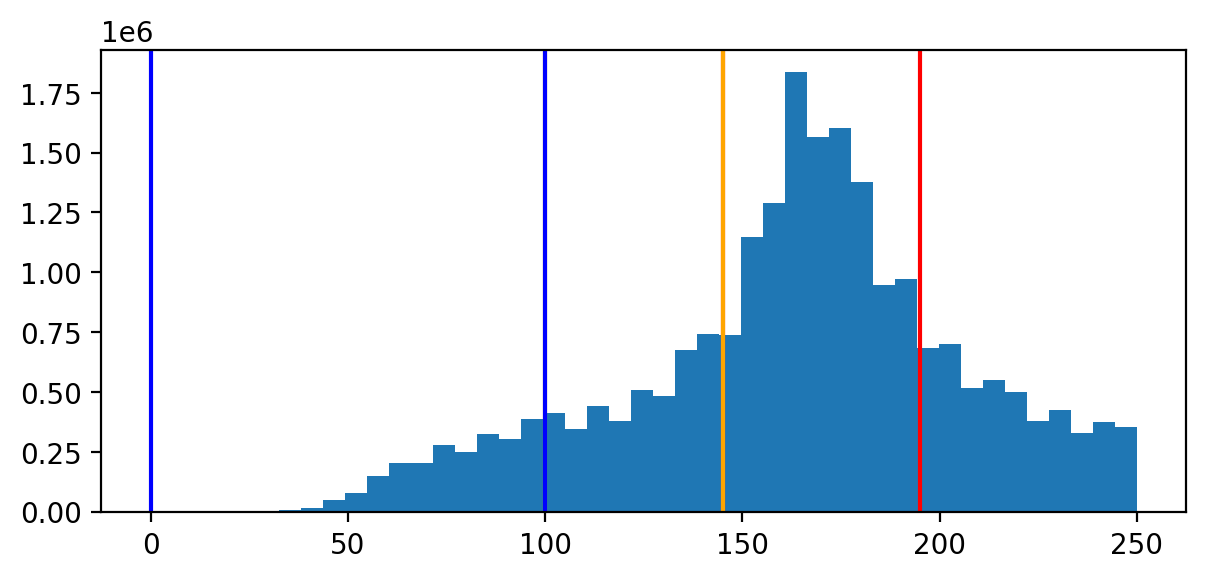

In [4]:
chromatin_metrics.plot_len_dist()

In [61]:
# Example plot of a gene and its counts
chromatin_metrics.set_chrom(1)

(0.03233478484000811, 0.10762900843352458)

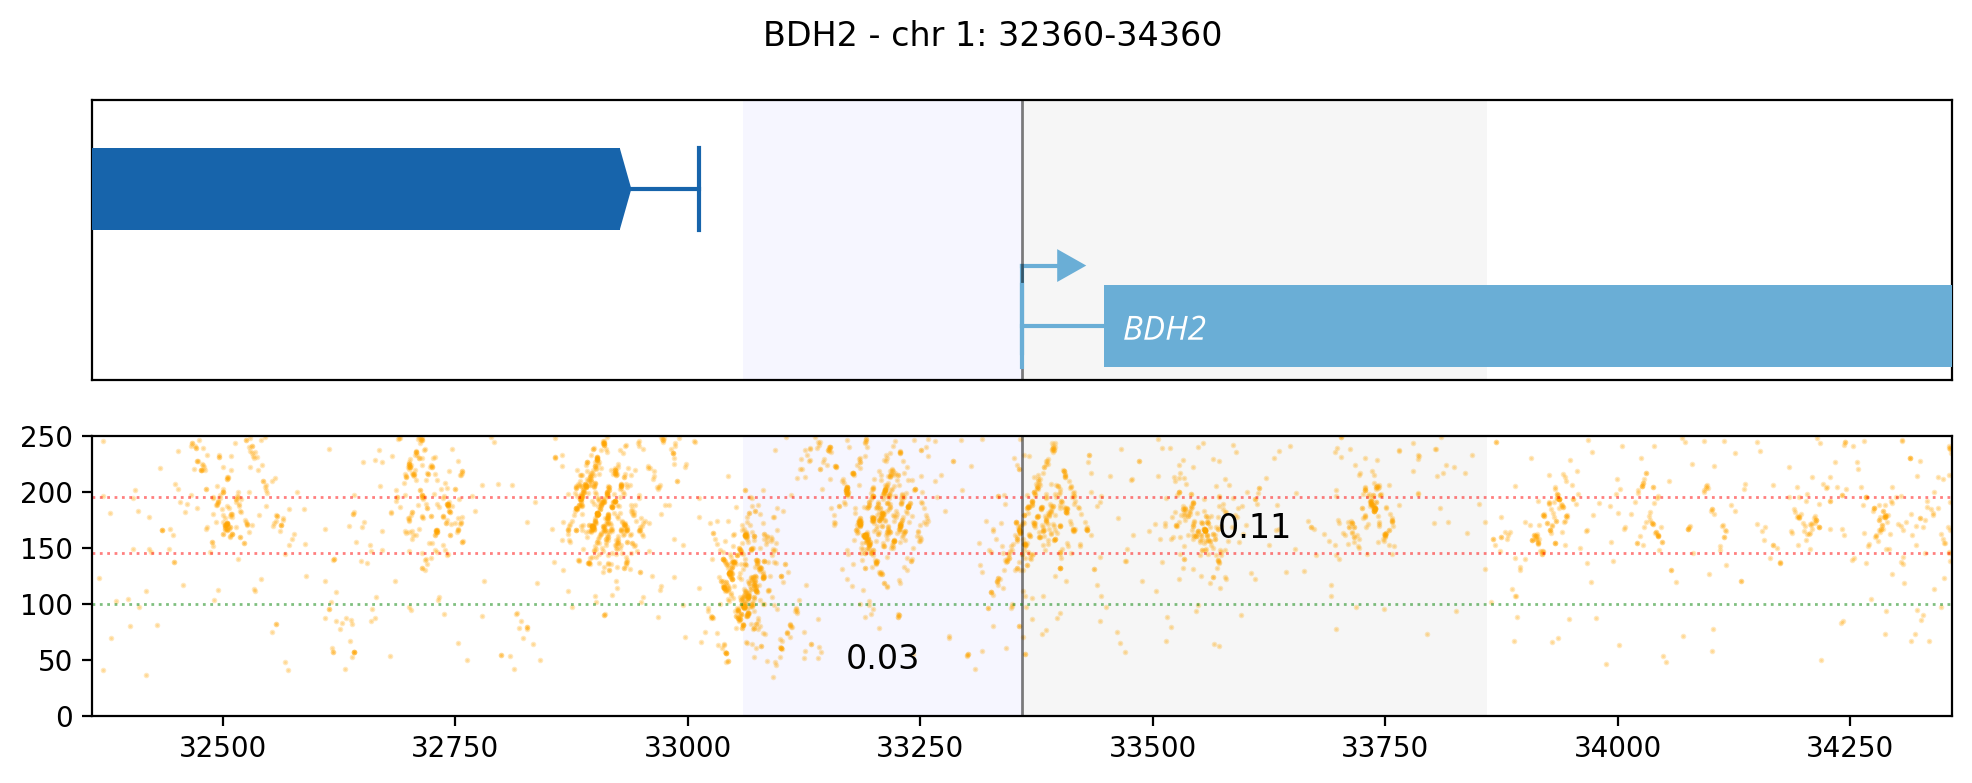

In [67]:
gene = chromatin_metrics.chrom_genes.iloc[10]
chromatin_metrics.plot_mnase_gene(gene, annotate_entropies=True)

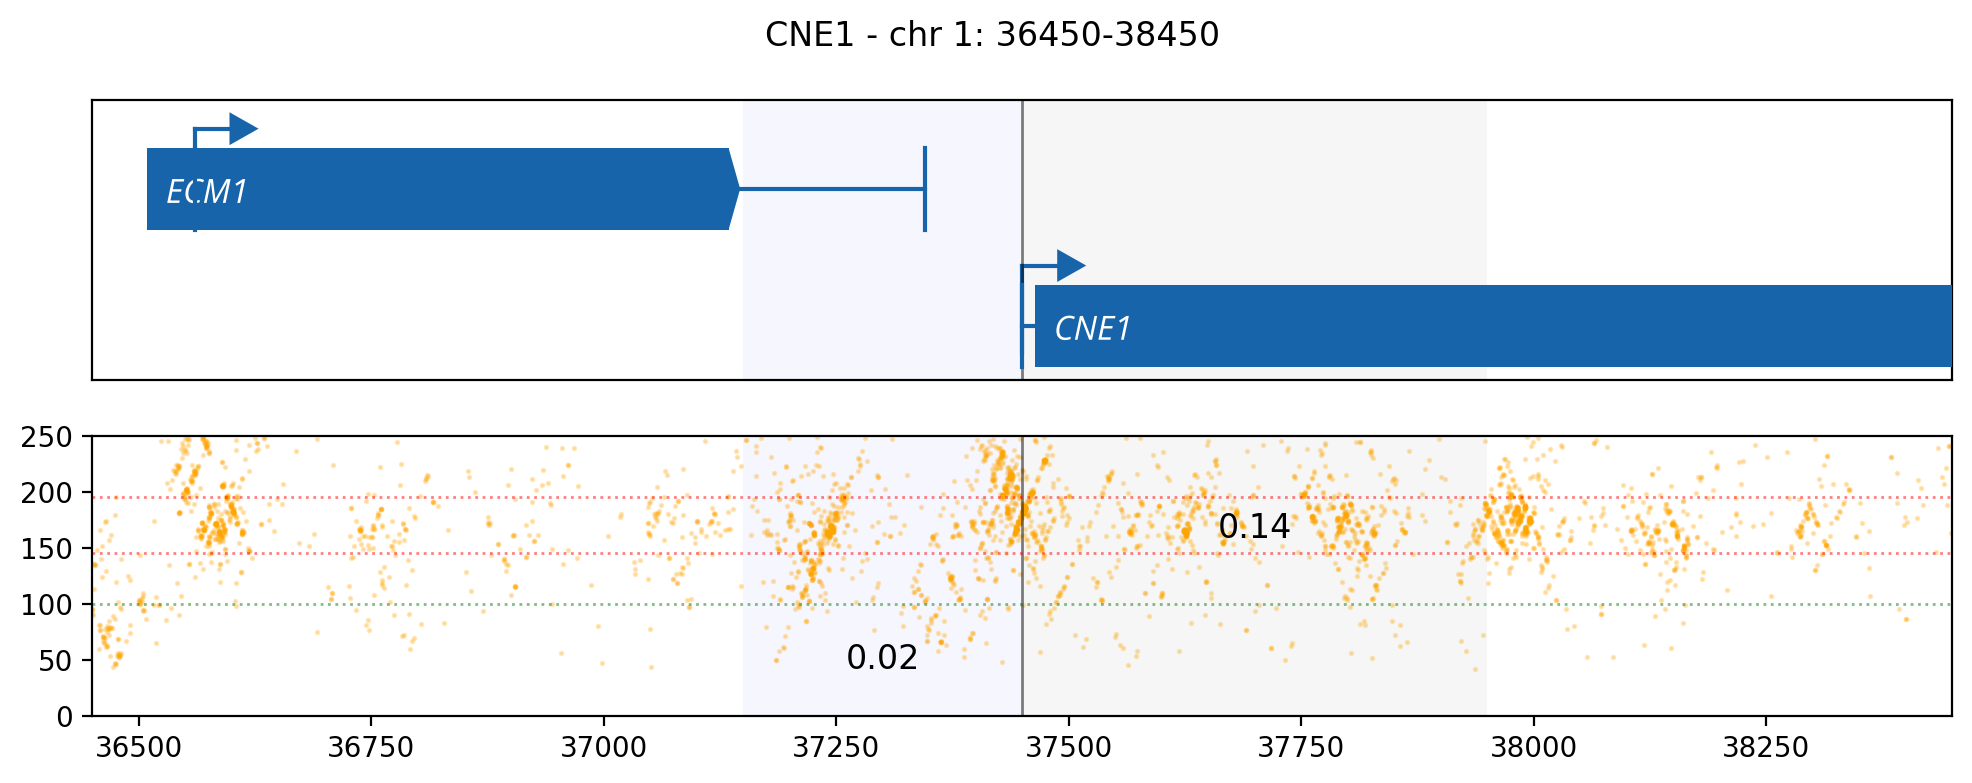

In [68]:
gene = chromatin_metrics.chrom_genes.iloc[13]
chromatin_metrics.plot_mnase_gene(gene, annotate_entropies=True)

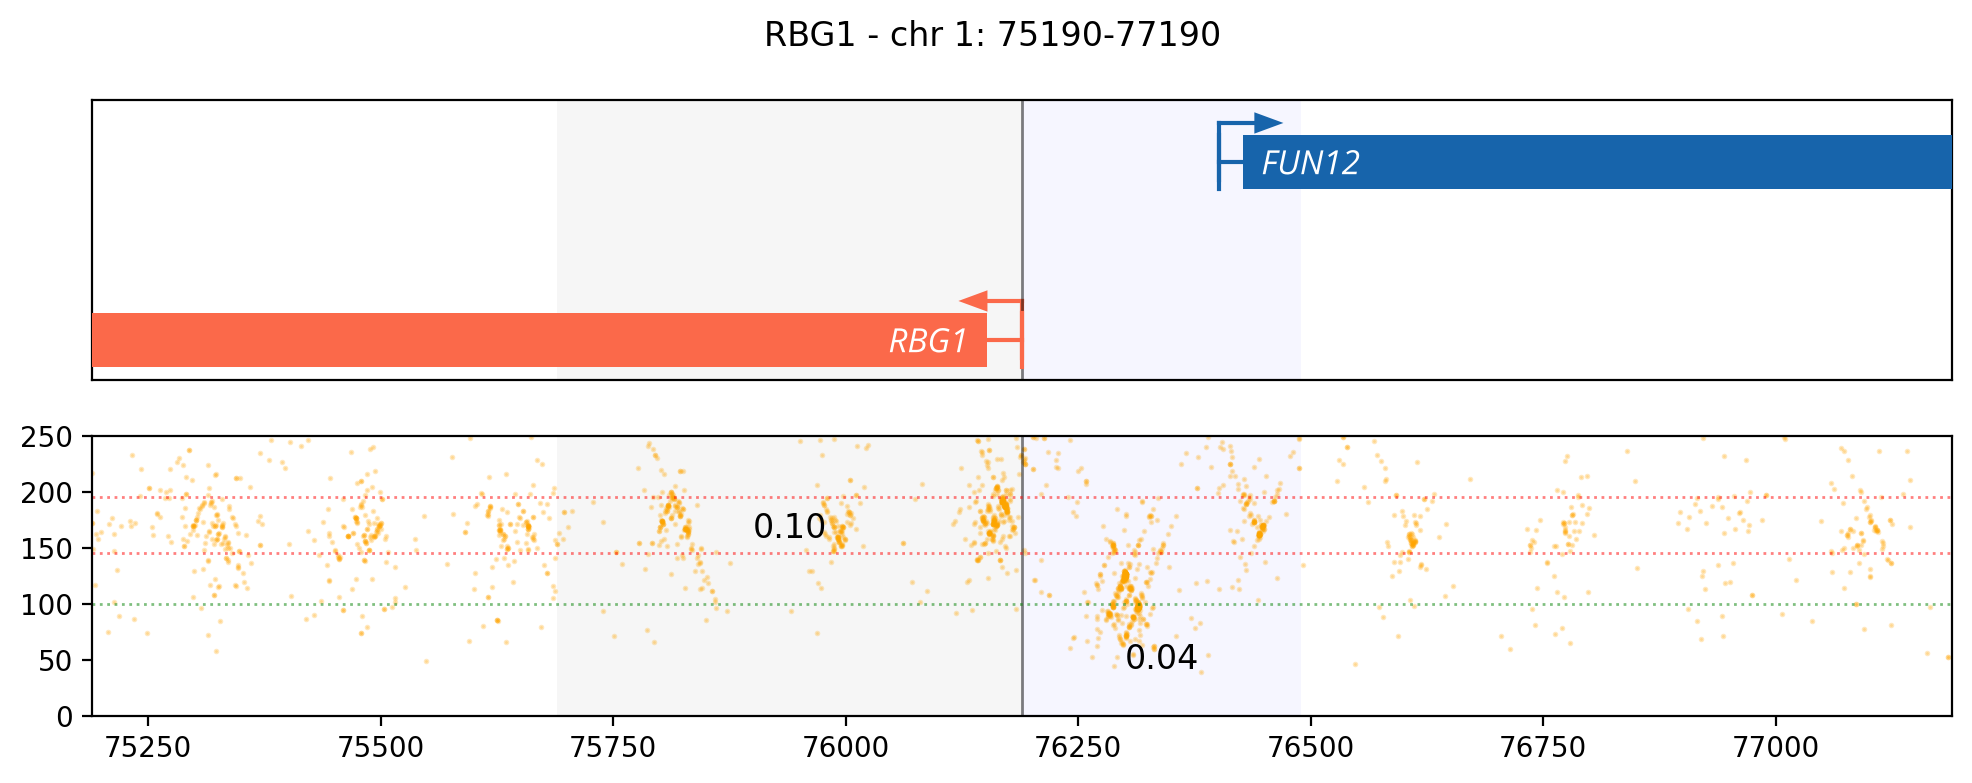

In [69]:
gene = chromatin_metrics.chrom_genes.iloc[33]
chromatin_metrics.plot_mnase_gene(gene, annotate_entropies=True)

In [82]:
from src.compute_chromatin_entropies import compute_rep2_chrom_entropies

compute_rep2_chrom_entropies()

Computing the entropy scores for the time point 0, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH82_MNase_rep2_0_min.bam
Reading in the bam file...
Computing gene entropies for all chromosomes...
Done with chromosome 1 - 00:00:00.47
Done with chromosome 2 - 00:00:03.62
Done with chromosome 3 - 00:00:04.46
Done with chromosome 4 - 00:00:13.17
Done with chromosome 5 - 00:00:15.12
Done with chromosome 6 - 00:00:15.67
Done with chromosome 7 - 00:00:20.60
Done with chromosome 8 - 00:00:22.50
Done with chromosome 9 - 00:00:23.72
Done with chromosome 10 - 00:00:26.49
Done with chromosome 11 - 00:00:28.87
Done with chromosome 12 - 00:00:34.40
Done with chromosome 13 - 00:00:38.55
Done with chromosome 14 - 00:00:41.66
Done with chromosome 15 - 00:00:46.93
Done with chromosome 16 - 00:00:51.14
Finished time point 0 - 00:02:48.35
Computing the entropy scores for the time point 10, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH83_MNase_rep2_10_min.bam
Reading in the bam f

Done with chromosome 11 - 00:00:29.06
Done with chromosome 12 - 00:00:34.60
Done with chromosome 13 - 00:00:38.73
Done with chromosome 14 - 00:00:41.72
Done with chromosome 15 - 00:00:47.04
Done with chromosome 16 - 00:00:51.19
Finished time point 90 - 00:33:06.01
Computing the entropy scores for the time point 100, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH92_MNase_rep2_100_min.bam
Reading in the bam file...
Computing gene entropies for all chromosomes...
Done with chromosome 1 - 00:00:00.44
Done with chromosome 2 - 00:00:03.85
Done with chromosome 3 - 00:00:04.66
Done with chromosome 4 - 00:00:13.72
Done with chromosome 5 - 00:00:15.66
Done with chromosome 6 - 00:00:16.23
Done with chromosome 7 - 00:00:21.45
Done with chromosome 8 - 00:00:23.33
Done with chromosome 9 - 00:00:24.58
Done with chromosome 10 - 00:00:27.41
Done with chromosome 11 - 00:00:29.83
Done with chromosome 12 - 00:00:35.57
Done with chromosome 13 - 00:00:39.87
Done with chromosome 14 - 00:00:43.11

# Post-processing

In [96]:
all_gene_entropies = pd.read_csv('saved_data/chromatin/yl_rep2_entropy_scores_2023-10-17/all_chromatin_gene_entropies_rep2.csv')
all_gene_entropies = all_gene_entropies.sort_values(['orf_name', 'time'])\
    .set_index(['orf_name', 'time'])
all_gene_entropies.head(2)

chr  prom_sm_occ  gb_nuc_occ
orf_name time                              
YAL001C  0       1     0.031949    0.204359
         10      1     0.054165    0.204499

In [98]:
from src.chromatin_metrics import create_save_deconvolution_datasets, make_matrix_pvt_df

# Save the individual entropies to disk
for col in all_gene_entropies.columns[1:]:
    save_filename = f'output/entropies_yl_rep2_{col}.tsv'
        
    # A table of just the chromatin entropies as tsv
    entropies_df = make_matrix_pvt_df(all_gene_entropies, col)
    create_save_deconvolution_datasets(entropies_df, col, save_filename)


Saved output/entropies_yl_rep2_prom_sm_occ.tsv
Saved output/entropies_yl_rep2_gb_nuc_occ.tsv
